# Laporan Praktikum DSP: Teori dan Implementasi
Notebook ini mendokumentasikan **dasar teori** dan **penerapan kode** untuk:
1. Operasi matematis sinyal digital
2. Analisa kawasan waktu
3. Analisa kawasan frekuensi

Setiap subbagian disusun dengan pola:
- **Cell markdown**: teori + rumus matematika
- **Cell code**: implementasi + visualisasi hasil

In [7]:
from pathlib import Path
import sys
import os
import importlib

import numpy as np
import matplotlib.pyplot as plt

# Cari root project: naik folder sampai ketemu main.py
project_root = Path.cwd()
while not (project_root / "main.py").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("Tidak menemukan main.py (root project tidak ketemu).")
    project_root = project_root.parent

# Tambahkan ke sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", project_root)

CWD: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS
PROJECT_ROOT: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS


In [8]:
import src.references as ref
ref = importlib.reload(ref)

import main
main = importlib.reload(main)

print("Import berhasil")
print("references file:", ref.__file__)
print("main file:", main.__file__)

Import berhasil
references file: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS\src\references.py
main file: c:\Users\HP\Documents\Kuliah\SMT 4\Pengolahan Sinyal Digital\DSP-Project-UTS\main.py


In [9]:
# Pilih sumber input: "synthetic" atau "audio"
INPUT_SOURCE = "synthetic"
AUDIO_PATH = os.path.join("assets", "gabungan domisol.mp3.mpeg")

result = main.main(
    input_source=INPUT_SOURCE,
    audio_path=AUDIO_PATH if INPUT_SOURCE == "audio" else None,
    show_plots=False,
    save_plots=False,
    verbose=False,
 )

x = result["signal"]
t = result["time"]
cfg = result["config"]
analysis = result["analysis"]
basic_ops = result["basic_operations"]

print("Sinyal siap dianalisis")
print("Panjang sinyal:", len(x))
print("Sampling rate:", cfg["fs"])

Menjalankan analisa utama dari src.references... mode=synthetic
Sampling rate yang dipakai: 1000 Hz

Selesai. main.py hanya sebagai input/config router.
Sinyal siap dianalisis
Panjang sinyal: 1000
Sampling rate: 1000


## 1. Operasi Matematis Sinyal Digital
Pada bagian ini, setiap operasi dijelaskan secara teori lalu divisualisasikan pada code cell.

### 1.1 Penjumlahan
Penjumlahan sinyal dengan konstanta ditulis:
$$
y[n] = x[n] + c
$$
dengan $c$ adalah konstanta (misalnya $-1$, $-0.5$, $0.5$, $1$).
Efek utamanya adalah pergeseran level amplitudo (DC shift).

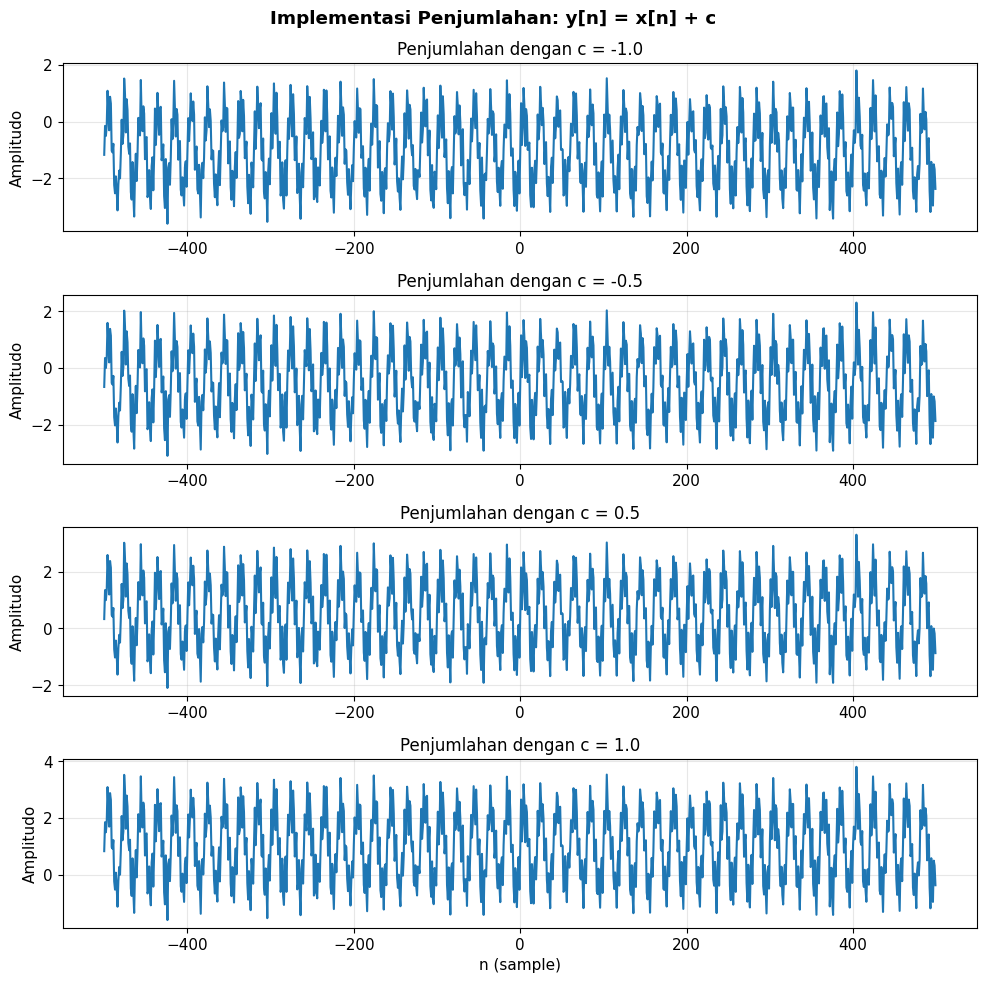

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))
fig.suptitle("Implementasi Penjumlahan: y[n] = x[n] + c", fontweight="bold")

keys = ["minus_1", "minus_05", "plus_05", "plus_1"]
labels = {
    "minus_1": "c = -1.0",
    "minus_05": "c = -0.5",
    "plus_05": "c = 0.5",
    "plus_1": "c = 1.0",
}

n_axis = basic_ops["signals"]["n"]
show_n = min(cfg["view_samples"], len(n_axis))
start = max(0, len(n_axis)//2 - show_n//2)
end = start + show_n

for ax, k in zip(axes, keys):
    ax.plot(n_axis[start:end], basic_ops["addition"][k][start:end])
    ax.set_title(f"Penjumlahan dengan {labels[k]}")
    ax.set_ylabel("Amplitudo")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("n (sample)")
plt.tight_layout()
plt.show()

### 1.2 Perkalian
Perkalian dua sinyal diskrit ditulis:
$$
y[n] = x[n] \cdot g[n]
$$
Pada percobaan ini, $g[n]$ dipilih sebagai impulse, step, ramp, dan sinyal konstan 1.

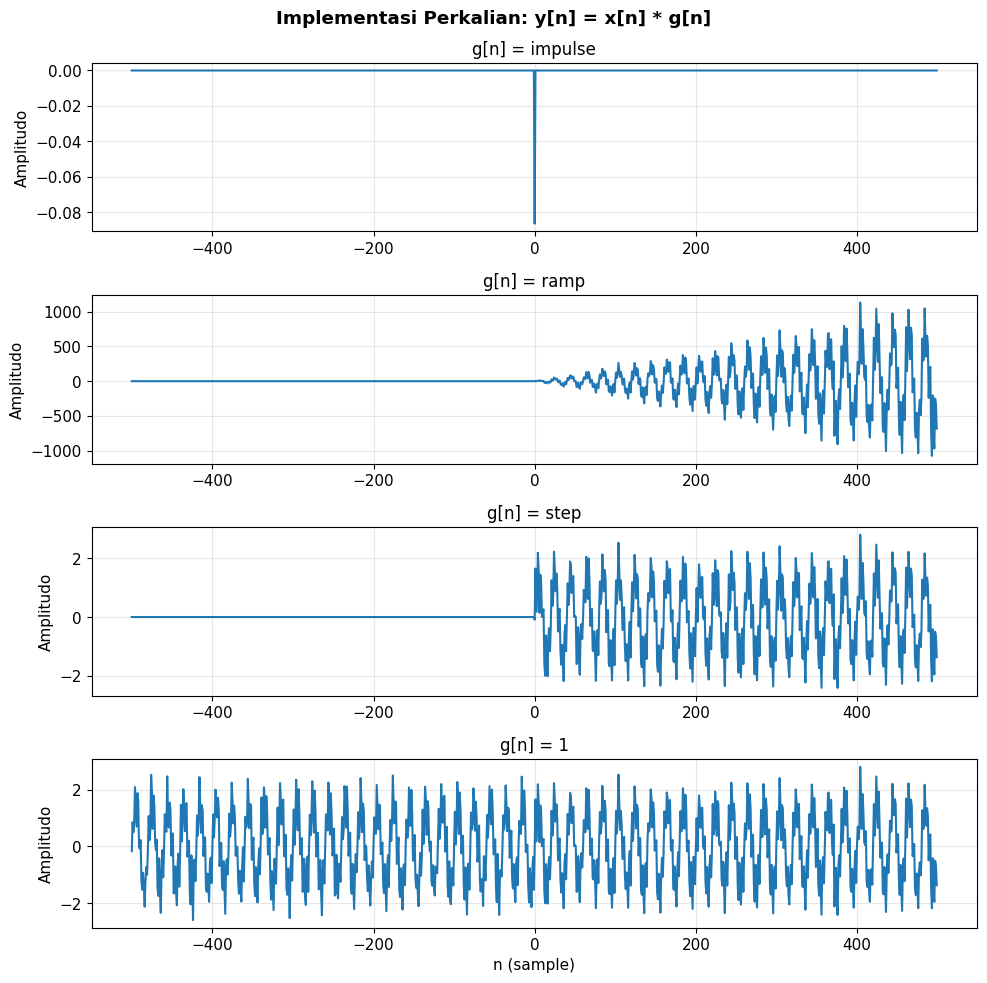

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))
fig.suptitle("Implementasi Perkalian: y[n] = x[n] * g[n]", fontweight="bold")

keys = ["impulse", "ramp", "step", "ones"]
labels = {
    "impulse": "g[n] = impulse",
    "ramp": "g[n] = ramp",
    "step": "g[n] = step",
    "ones": "g[n] = 1",
}

for ax, k in zip(axes, keys):
    ax.plot(n_axis[start:end], basic_ops["multiplication"][k][start:end])
    ax.set_title(labels[k])
    ax.set_ylabel("Amplitudo")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("n (sample)")
plt.tight_layout()
plt.show()

### 1.3 Konvolusi
Konvolusi diskrit didefinisikan sebagai:
$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$
Pada implementasi ini, kernel $h[n]$ dicoba dalam bentuk impulse, step, ramp, dan ones.

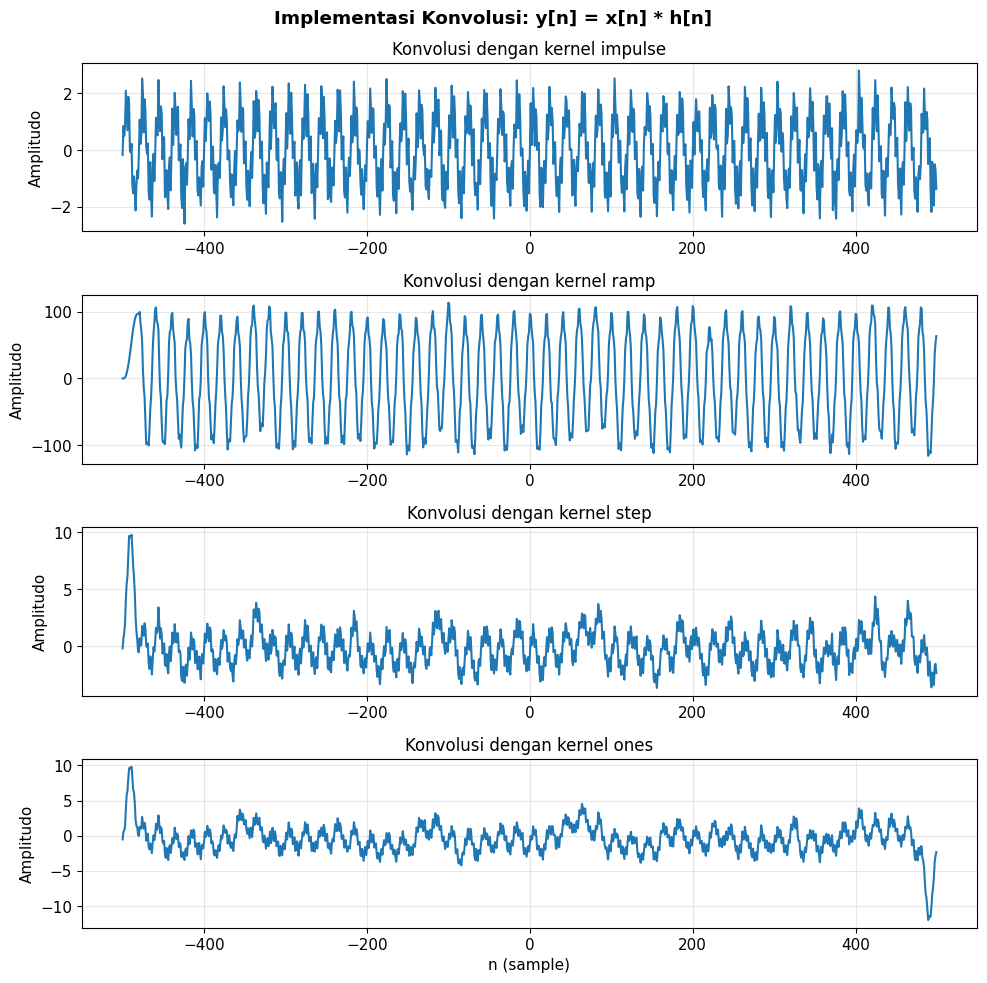

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))
fig.suptitle("Implementasi Konvolusi: y[n] = x[n] * h[n]", fontweight="bold")

for ax, k in zip(axes, keys):
    ax.plot(n_axis[start:end], basic_ops["convolution"][k][start:end])
    ax.set_title(f"Konvolusi dengan kernel {k}")
    ax.set_ylabel("Amplitudo")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("n (sample)")
plt.tight_layout()
plt.show()

### 1.4 Korelasi dan Normalisasi
Korelasi diskrit (cross-correlation) dapat ditulis:
$$
r_{xy}[m] = \sum_n x[n] y[n+m]
$$
Khusus auto-korelasi ketika $y[n] = x[n]$, puncak biasanya muncul di lag 0.

Normalisasi yang digunakan:
$$
x_{peak}[n] = \frac{x[n]}{\max |x[n]|}, \quad
x_{z}[n] = \frac{x[n]-\mu_x}{\sigma_x}
$$

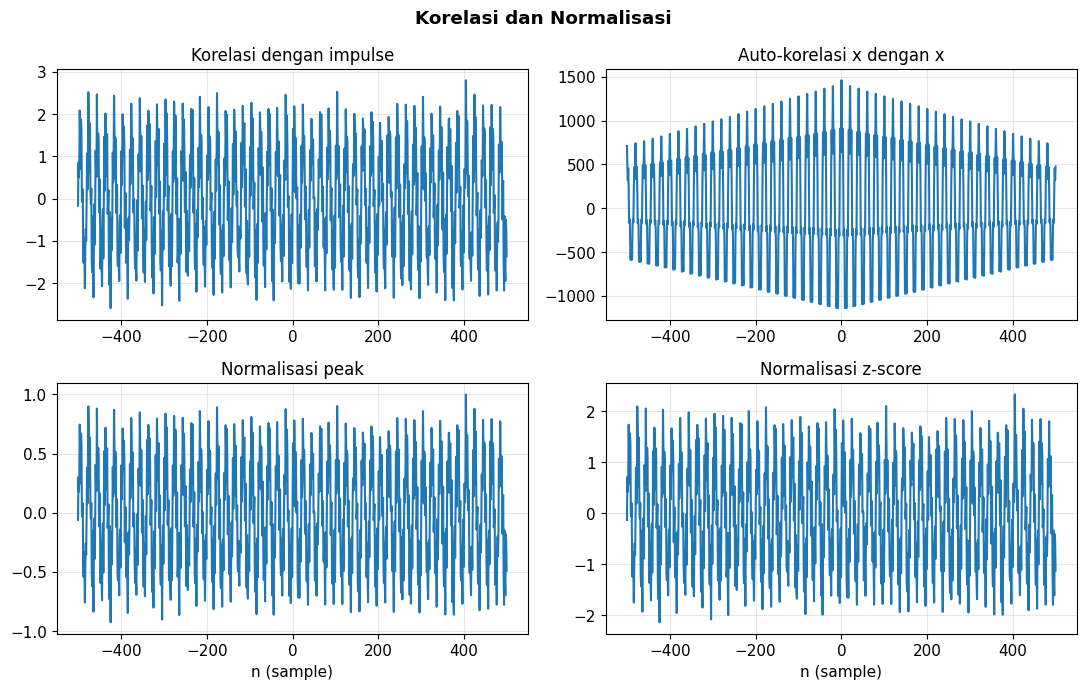

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Korelasi dan Normalisasi", fontweight="bold")

axes[0, 0].plot(n_axis[start:end], basic_ops["correlation"]["impulse"][start:end])
axes[0, 0].set_title("Korelasi dengan impulse")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(n_axis[start:end], basic_ops["correlation"]["self"][start:end])
axes[0, 1].set_title("Auto-korelasi x dengan x")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(n_axis[start:end], basic_ops["normalization"]["peak"][start:end])
axes[1, 0].set_title("Normalisasi peak")
axes[1, 0].set_xlabel("n (sample)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(n_axis[start:end], basic_ops["normalization"]["zscore"][start:end])
axes[1, 1].set_title("Normalisasi z-score")
axes[1, 1].set_xlabel("n (sample)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Analisa Kawasan Waktu
Kawasan waktu mengamati perubahan amplitudo terhadap waktu/sample.

Komponen yang dianalisis:
- Sinyal asli $x[n]$
- Clipping
- Daya sesaat $p[n] = x[n]^2$
- RMS:
$$
x_{RMS} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}
$$
- Moving average (filter low-pass sederhana).

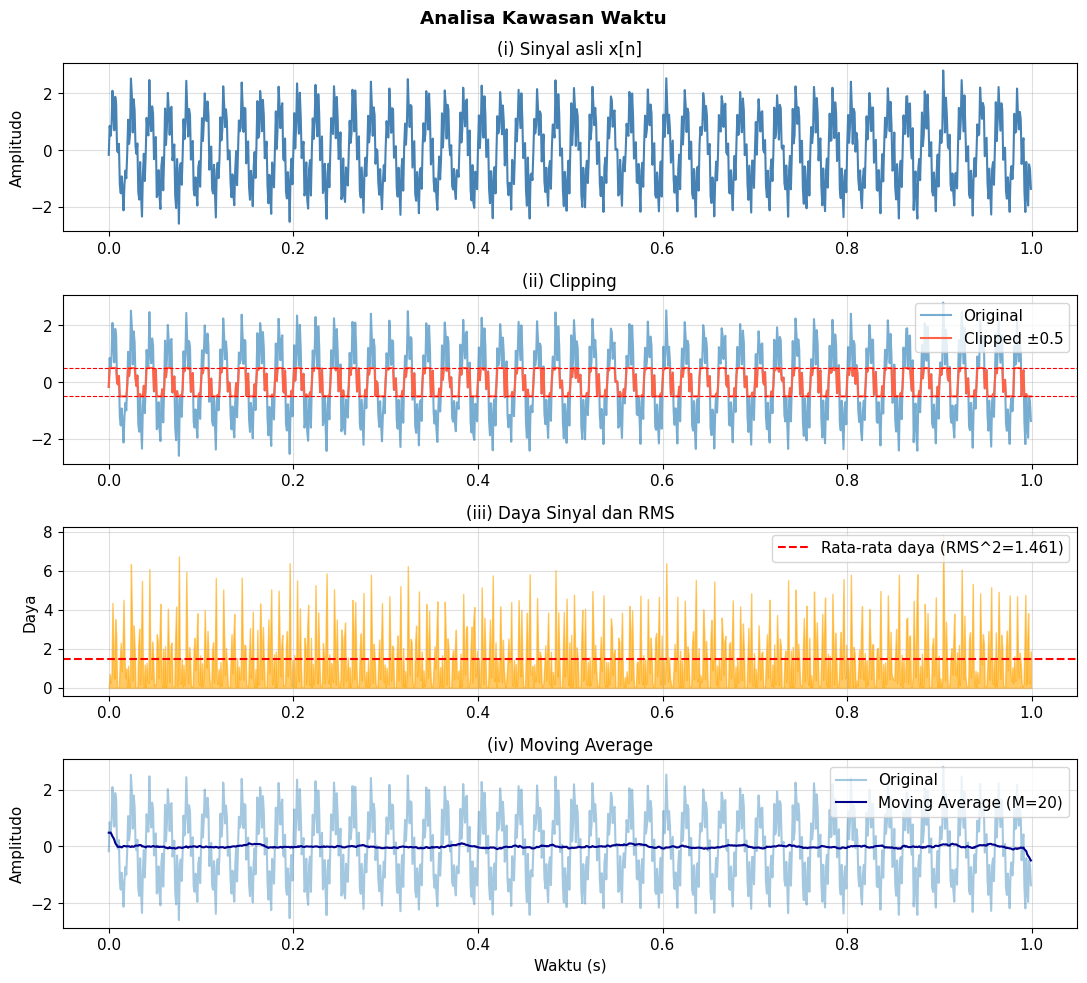

In [14]:
x_clipped = analysis["x_clipped"]
x_power = analysis["x_power"]
x_ma = analysis["x_ma"]
rms_val = analysis["rms_val"]

show_n_t = min(max(cfg["view_samples"], int(0.05 * cfg["fs"])), len(x))
start_t = 0
end_t = start_t + show_n_t

fig, axes = plt.subplots(4, 1, figsize=(11, 10))
fig.suptitle("Analisa Kawasan Waktu", fontweight="bold")

axes[0].plot(t[start_t:end_t], x[start_t:end_t], color="steelblue")
axes[0].set_title("(i) Sinyal asli x[n]")
axes[0].set_ylabel("Amplitudo")

axes[1].plot(t[start_t:end_t], x[start_t:end_t], label="Original", alpha=0.6)
axes[1].plot(t[start_t:end_t], x_clipped[start_t:end_t], label=f"Clipped ±{cfg['clip_level']}", color="tomato")
axes[1].axhline(cfg["clip_level"], color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-cfg["clip_level"], color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("(ii) Clipping")
axes[1].legend(loc="upper right")

axes[2].fill_between(t[start_t:end_t], 0, x_power[start_t:end_t], color="orange", alpha=0.6)
axes[2].axhline(rms_val**2, color="red", linestyle="--", label=f"Rata-rata daya (RMS^2={rms_val**2:.3f})")
axes[2].set_title("(iii) Daya Sinyal dan RMS")
axes[2].set_ylabel("Daya")
axes[2].legend(loc="upper right")

axes[3].plot(t[start_t:end_t], x[start_t:end_t], label="Original", alpha=0.4)
axes[3].plot(t[start_t:end_t], x_ma[start_t:end_t], label=f"Moving Average (M={cfg['ma_window']})", color="darkblue")
axes[3].set_title("(iv) Moving Average")
axes[3].set_xlabel("Waktu (s)")
axes[3].set_ylabel("Amplitudo")
axes[3].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. Analisa Kawasan Frekuensi
Transformasi Fourier Diskrit (DFT):
$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi kn/N}
$$
Dari $X[k]$ kita analisis:
- amplitudo $|X[k]|$
- energi $|X[k]|^2$
- komponen real dan imajiner
- phase
- dampak operasi sinyal terhadap spektrum

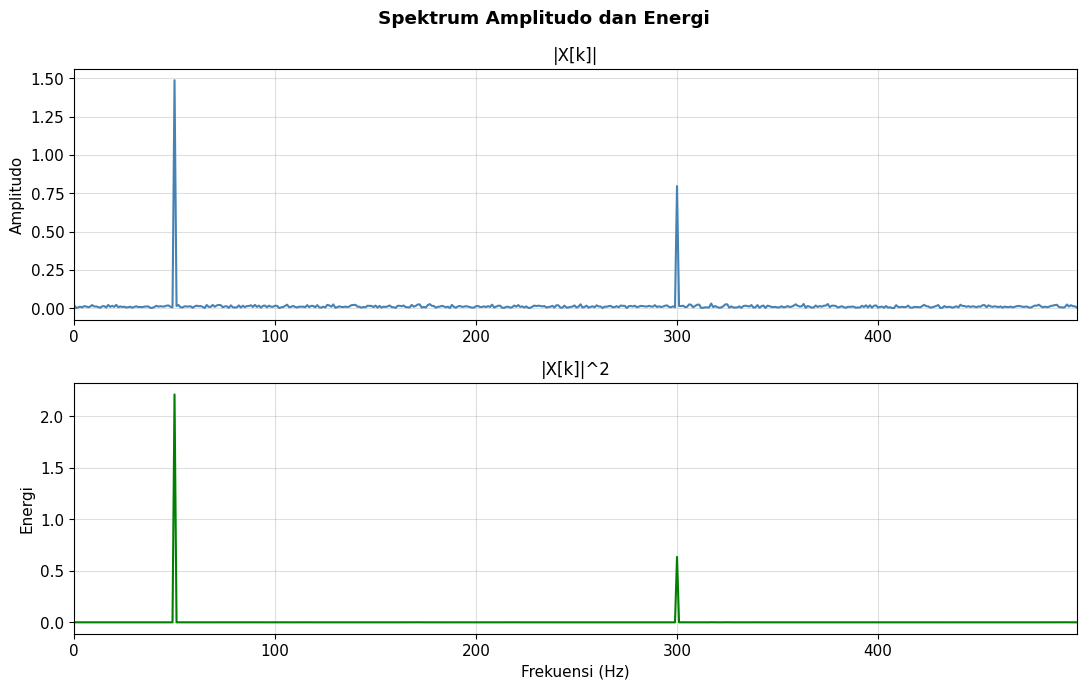

In [15]:
f_pos = analysis["f_pos"]
amp = analysis["amp"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
fig.suptitle("Spektrum Amplitudo dan Energi", fontweight="bold")

axes[0].plot(f_pos, amp, color="steelblue")
axes[0].set_title("|X[k]|")
axes[0].set_ylabel("Amplitudo")
axes[0].set_xlim(0, min(500, f_pos[-1]))

axes[1].plot(f_pos, amp**2, color="green")
axes[1].set_title("|X[k]|^2")
axes[1].set_xlabel("Frekuensi (Hz)")
axes[1].set_ylabel("Energi")
axes[1].set_xlim(0, min(500, f_pos[-1]))

plt.tight_layout()
plt.show()

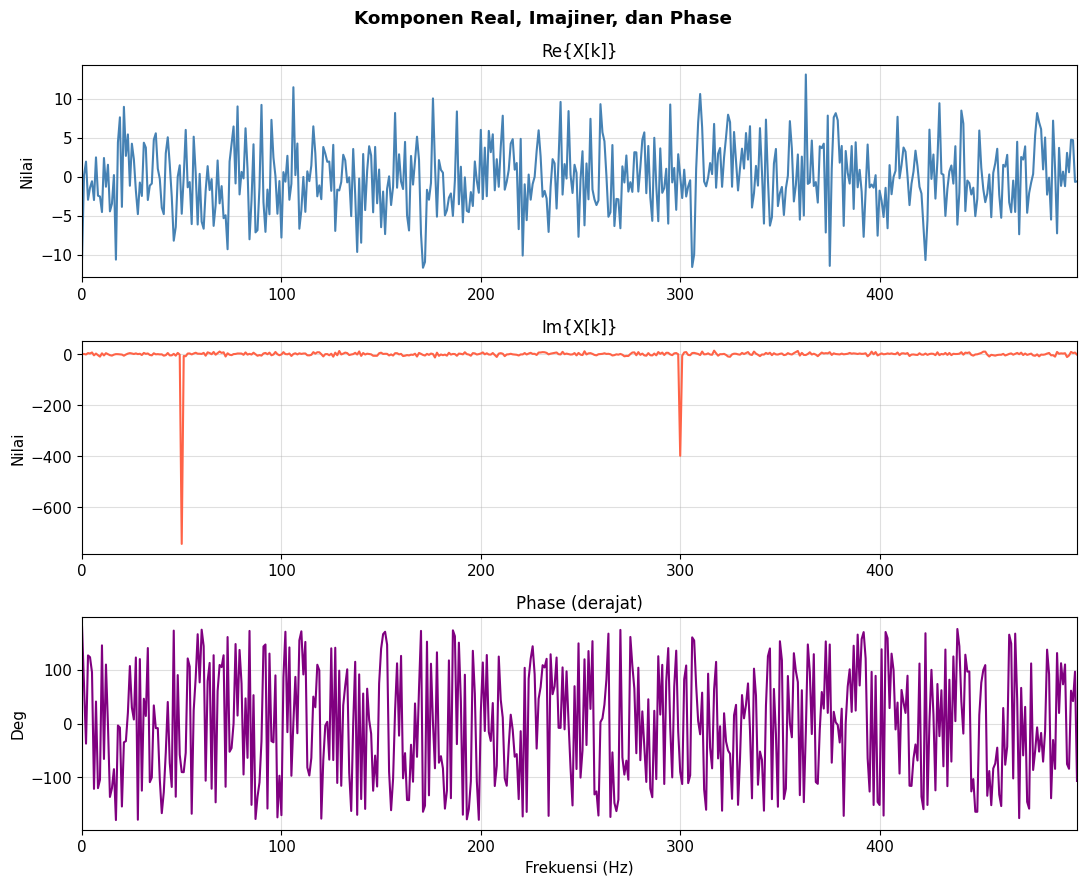

In [16]:
re_X = analysis["re_X"]
im_X = analysis["im_X"]
phase_deg = np.degrees(analysis["phase_X"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9))
fig.suptitle("Komponen Real, Imajiner, dan Phase", fontweight="bold")

axes[0].plot(f_pos, re_X, color="steelblue")
axes[0].set_title("Re{X[k]}")
axes[0].set_ylabel("Nilai")
axes[0].set_xlim(0, min(500, f_pos[-1]))

axes[1].plot(f_pos, im_X, color="tomato")
axes[1].set_title("Im{X[k]}")
axes[1].set_ylabel("Nilai")
axes[1].set_xlim(0, min(500, f_pos[-1]))

axes[2].plot(f_pos, phase_deg, color="purple")
axes[2].set_title("Phase (derajat)")
axes[2].set_xlabel("Frekuensi (Hz)")
axes[2].set_ylabel("Deg")
axes[2].set_xlim(0, min(500, f_pos[-1]))

plt.tight_layout()
plt.show()

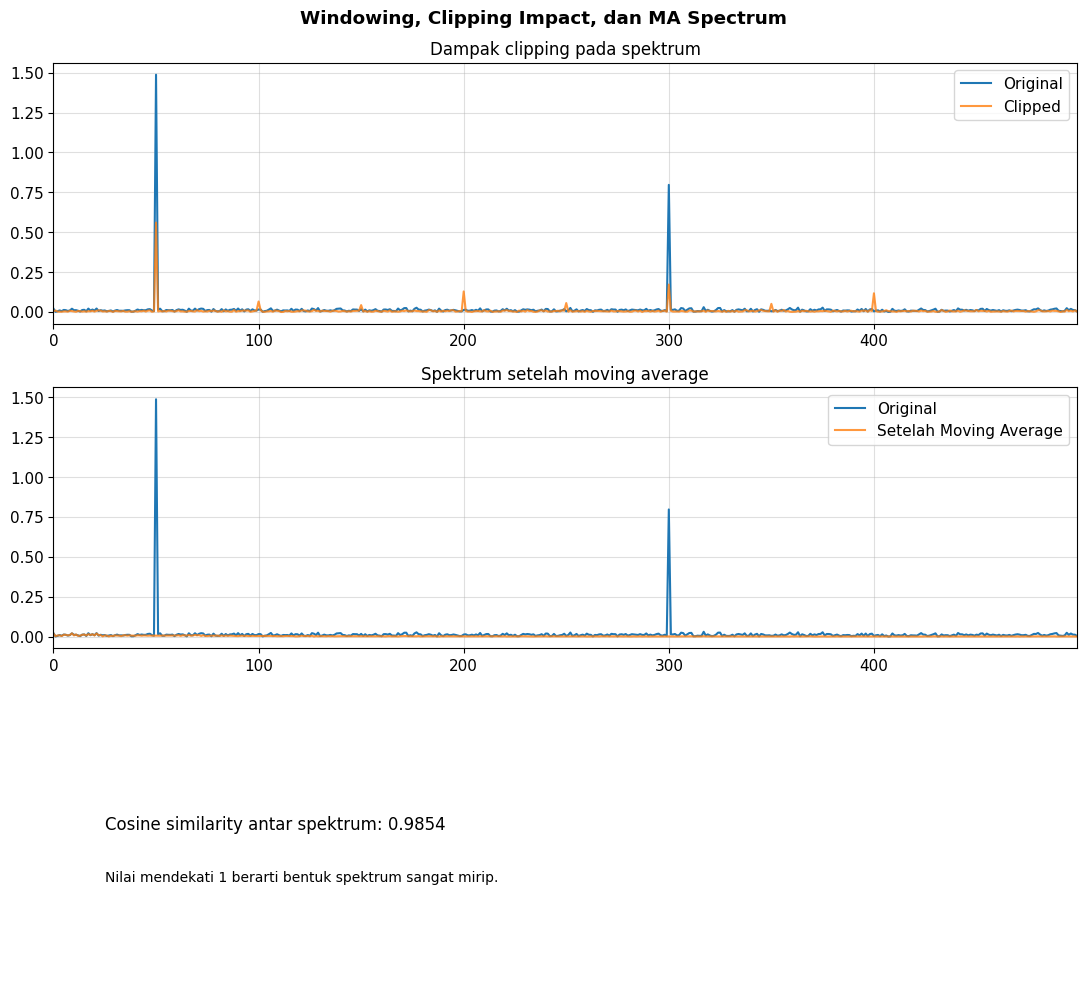

In [17]:
# Ringkasan analisa frekuensi lanjutan
amp_c = analysis["amp_c"]
amp_ma = analysis["amp_ma"]
similarity = result["similarity"]

fig, axes = plt.subplots(3, 1, figsize=(11, 10))
fig.suptitle("Windowing, Clipping Impact, dan MA Spectrum", fontweight="bold")

axes[0].plot(f_pos, amp, label="Original")
axes[0].plot(f_pos, amp_c, label="Clipped", alpha=0.8)
axes[0].set_title("Dampak clipping pada spektrum")
axes[0].set_xlim(0, min(500, f_pos[-1]))
axes[0].legend()

axes[1].plot(f_pos, amp, label="Original")
axes[1].plot(f_pos, amp_ma, label="Setelah Moving Average", alpha=0.8)
axes[1].set_title("Spektrum setelah moving average")
axes[1].set_xlim(0, min(500, f_pos[-1]))
axes[1].legend()

axes[2].text(0.05, 0.55, f"Cosine similarity antar spektrum: {similarity:.4f}", fontsize=12)
axes[2].text(0.05, 0.35, "Nilai mendekati 1 berarti bentuk spektrum sangat mirip.", fontsize=10)
axes[2].set_axis_off()

plt.tight_layout()
plt.show()